In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Check available sheet names first
xls = pd.ExcelFile('../data/online_retail_II.xlsx')
print(xls.sheet_names)

['Year 2009-2010', 'Year 2010-2011']


In [4]:
# Load each sheet into its own DataFrame
df_2009_2010 = pd.read_excel(xls, sheet_name='Year 2009-2010')
df_2010_2011 = pd.read_excel(xls, sheet_name='Year 2010-2011')

In [5]:
df_2009_2010["SourceSheet"] = "2009-2010"
df_2010_2011["SourceSheet"] = "2010-2011"

In [6]:
# Combine into one DataFrame
df_all = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)
df = df_all.copy()

In [7]:
df.head(3)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010


In [8]:
df.isna().sum() 

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
SourceSheet         0
dtype: int64

In [9]:
# Let's check how big dataset is.
# .shape gives us (number of rows, number of columns).
print("The dataset has:", df.shape[0], "rows and", df.shape[1], "columns")

The dataset has: 1067371 rows and 9 columns


In [10]:

# List the column names so we know exactly what we have.
print("\nColumns:", list(df.columns))


Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'SourceSheet']


In [11]:
# Information in dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
 8   SourceSheet  1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(2)
memory usage: 73.3+ MB


## Data Cleaning

### 1. Fix data types

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Invoice'] = df['Invoice'].astype(str).str.strip()
df['StockCode'] = df['StockCode'].astype(str).str.strip().str.upper()
df['Description'] = df['Description'].astype(str).str.strip()
df['Country'] = df['Country'].astype(str).str.strip()

### 2. Remove exact duplicate rows

In [13]:
# Show the duplicated rows (all occurrences, not just the extra copies)
duplicate_rows = df[df.duplicated(subset=list(df.columns), keep=False)]
print(f"Found {len(duplicate_rows)} rows involved in duplication")
duplicate_rows.sort_values(by=list(df.columns)).head(10)

Found 23430 rows involved in duplication


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,2009-2010
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom,2009-2010
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom,2009-2010
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom,2009-2010


In [14]:
# 2. Remove exact duplicate rows
before = len(df)
df_clean = df.drop_duplicates(list(df.columns))
print(f"Dropped {before - len(df_clean)} exact duplicate rows -> {len(df_clean)} left")

Dropped 12133 exact duplicate rows -> 1055238 left


### 3. Drop rows with missing Customer ID

In [15]:
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Customer ID'])
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int)
print(f"Dropped {before - len(df_clean)} rows with missing Customer ID -> {len(df_clean)} left")

Dropped 242870 rows with missing Customer ID -> 812368 left


### 4. Drop rows with missing Description

In [16]:
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Description'])
print(f"Dropped {before - len(df_clean)} rows with missing Description -> {len(df_clean)} left")

Dropped 0 rows with missing Description -> 812368 left


### 5. Remove non-product / administrative stock codes

In [17]:
# -----------------------------------------------------------------------
# 5. Remove non-product / administrative stock codes
# -----------------------------------------------------------------------
# These codes are postage, fees, manual adjustments, bank charges, samples,
# discounts and test entries — not real products, so they'd distort RFM,
# segmentation and product-level analysis.
admin_codes = [
    'POST', 'DOT', 'M', 'C2', 'D', 'S', 'BANK CHARGES',
    'ADJUST', 'ADJUST2', 'AMAZONFEE', 'CRUK', 'TEST001', 'TEST002', 'B'
]
before = len(df_clean)
df_clean = df_clean[~df_clean['StockCode'].isin(admin_codes)]
print(f"Dropped {before - len(df_clean)} rows with admin/non-product stock codes -> {len(df_clean)} left")


Dropped 3706 rows with admin/non-product stock codes -> 808662 left


### 6. Separate cancellations (returns) from the sales dataset

Invoices starting with 'C' are cancellations. Keep them in a separate  dataframe in case you want to analyze returns later,
but exclude them  from the "sales" dataset used for RFM/segmentation/prediction.

In [18]:
is_cancelled = df_clean['Invoice'].str.startswith('C')
df_returns = df_clean[is_cancelled].copy()
df_clean = df_clean[~is_cancelled].copy()
print(f"Separated {len(df_returns)} cancelled-order rows into df_returns -> {len(df_clean)} sales rows left")

Separated 17879 cancelled-order rows into df_returns -> 790783 sales rows left


### 7. Remove non-positive quantities and prices
A handful of negative-quantity rows aren't flagged as cancellations , and  zero/negative prices are data errors 
or free/adjustment items with no real revenue signal.

In [19]:
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]
print(f"Dropped {before - len(df_clean)} rows with Quantity <= 0 or Price <= 0 -> {len(df_clean)} left")

Dropped 62 rows with Quantity <= 0 or Price <= 0 -> 790721 left


In [20]:
# -----------------------------------------------------------------------
# 8. Remove extreme price outliers (optional sanity cap)
# -----------------------------------------------------------------------
# A few Price values are in the thousands and clearly not per-unit retail  prices.
#Flag anything beyond the 99.9th percentile for review instead of  silently dropping, so you can decide case by case.
#price_cap = df_clean['Price'].quantile(0.999)
#n_outliers = (df_clean['Price'] > price_cap).sum()
#print(f"{n_outliers} rows have Price above the 99.9th percentile ({price_cap:.2f}) — inspect before deciding to cap/drop")

### 9. Add the Revenue column (needed for EDA/RFM downstream)

In [21]:
df_clean= df_clean.drop(columns=['SourceSheet'])

In [22]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']
df_clean.head(2)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0


### Final Data cleaning Summary

In [23]:
df_clean = df_clean.reset_index(drop=True)
print("\n==== CLEANING SUMMARY ====")
print(f"Raw rows:        {len(df):,}")
print(f"Clean sales rows:{len(df_clean):,}")
print(f"Returns rows:    {len(df_returns):,}")
print(f"Remaining missing values:\n{df_clean.isna().sum()}")


==== CLEANING SUMMARY ====
Raw rows:        1,067,371
Clean sales rows:790,721
Returns rows:    17,879
Remaining missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64


## Exploratory Data Analysis (EDA)

### Overview of cleaned dataset

In [24]:
print("=== 1. OVERVIEW ===")
print(f"Rows: {df_clean.shape[0]:,} | Columns: {df_clean.shape[1]}")
print(f"Date range: {df_clean['InvoiceDate'].min()} -> {df_clean['InvoiceDate'].max()}")
print("Time span:", df_clean['InvoiceDate'].max() - df_clean['InvoiceDate'].min())
print(f"Unique customers: {df_clean['Customer ID'].nunique():,}")
print(f"Unique invoices: {df_clean['Invoice'].nunique():,}")
print(f"Unique products (StockCode): {df_clean['StockCode'].nunique():,}")
print(f"Unique countries: {df_clean['Country'].nunique()}")

=== 1. OVERVIEW ===
Rows: 790,721 | Columns: 9
Date range: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Time span: 738 days 05:05:00
Unique customers: 5,852
Unique invoices: 36,594
Unique products (StockCode): 4,621
Unique countries: 41


### 2. Descriptive statistics


=== 2. DESCRIPTIVE STATISTICS ===
            Quantity          Price        Revenue
count  790721.000000  790721.000000  790721.000000
mean       13.476514       2.936808      21.976000
std       144.931071       4.297986     224.229264
min         1.000000       0.001000       0.001000
25%         2.000000       1.250000       4.950000
50%         6.000000       1.950000      11.900000
75%        12.000000       3.750000      19.800000
max     80995.000000     649.500000  168469.600000


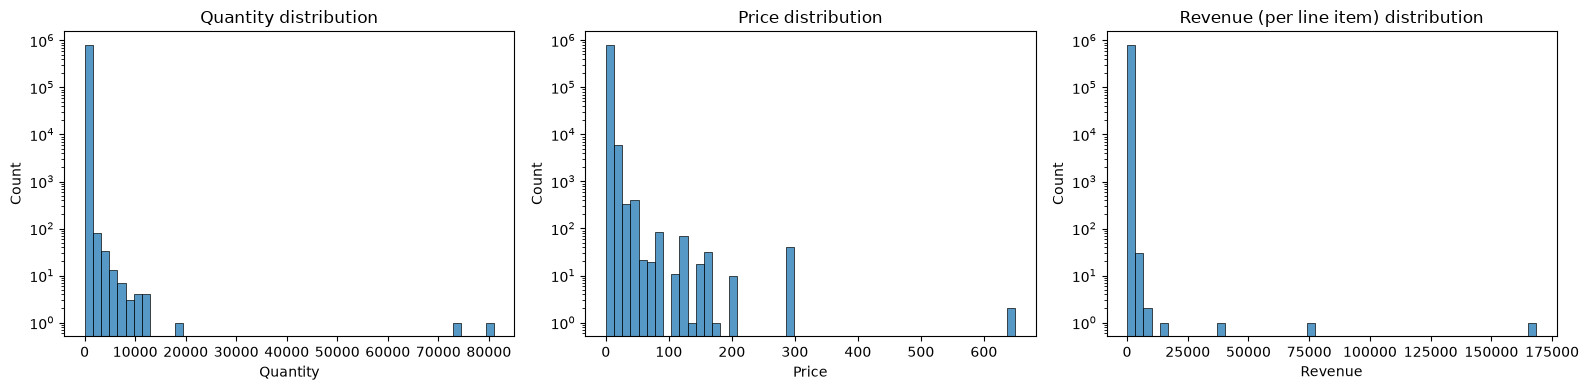

In [25]:
print("\n=== 2. DESCRIPTIVE STATISTICS ===")
print(df_clean[['Quantity', 'Price', 'Revenue']].describe())
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_clean['Quantity'], bins=50, ax=axes[0])
axes[0].set_title('Quantity distribution')
axes[0].set_yscale('log')
 
sns.histplot(df_clean['Price'], bins=50, ax=axes[1])
axes[1].set_title('Price distribution')
axes[1].set_yscale('log')
 
sns.histplot(df_clean['Revenue'], bins=50, ax=axes[2])
axes[2].set_title('Revenue (per line item) distribution')
axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

### 3. Revenue over time


======================= 3. MONTHLY REVENUE TREND =========================


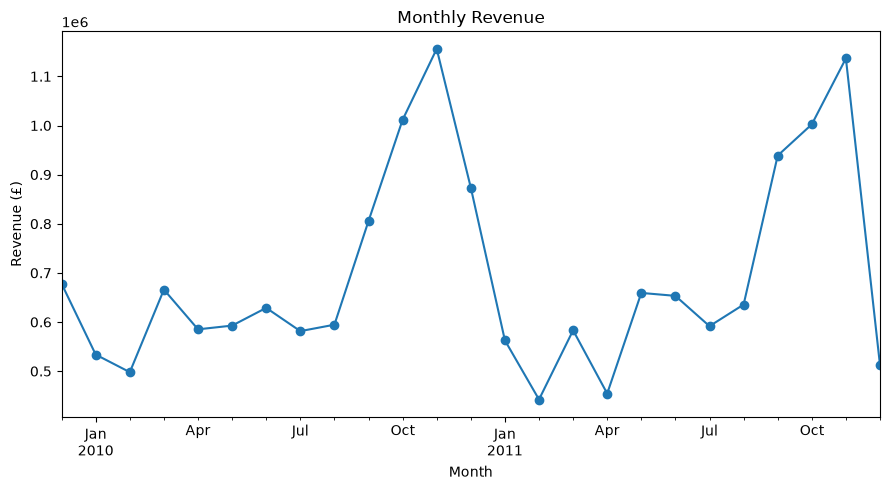

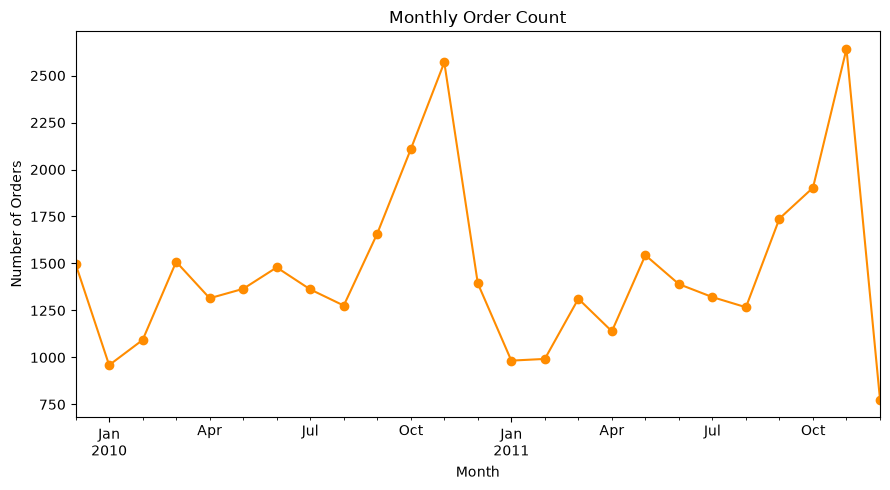

In [26]:
print("\n======================= 3. MONTHLY REVENUE TREND =========================")
monthly_revenue = (
    df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum()
    .to_timestamp()
)
plt.figure(figsize=(9, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()
 
monthly_orders = (
    df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M'))['Invoice']
    .nunique()
    .to_timestamp()
)
plt.figure(figsize=(9, 5))
monthly_orders.plot(kind='line', marker='o', color='darkorange')
plt.title('Monthly Order Count')
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.tight_layout()
plt.show()


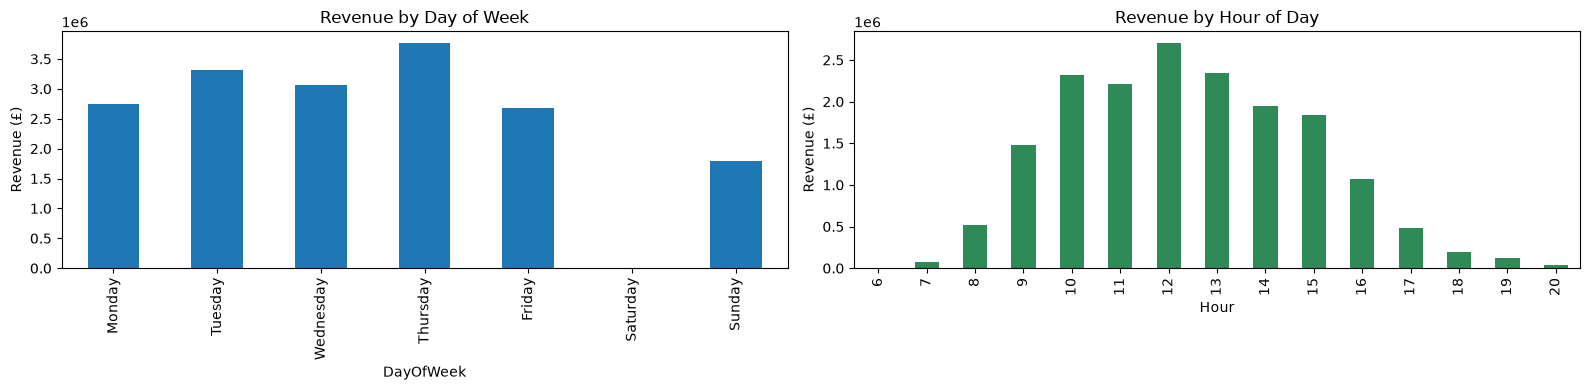

In [27]:
# Day-of-week and hour-of-day patterns
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
 
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
df_clean.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order).plot(kind='bar', ax=axes[0])
axes[0].set_title('Revenue by Day of Week')
axes[0].set_ylabel('Revenue (£)')
 
df_clean.groupby('Hour')['Revenue'].sum().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_ylabel('Revenue (£)')
plt.tight_layout()
plt.show()


### Top products


=== 4. TOP PRODUCTS ===
Top 10 by quantity sold:
 Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108929
WHITE HANGING HEART T-LIGHT HOLDER     93520
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          79694
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                75597
BROCADE RING PURSE                     71093
PACK OF 60 PINK PAISLEY CAKE CASES     55101
60 TEATIME FAIRY CAKE CASES            53320
PACK OF 72 RETROSPOT CAKE CASES        46046
Name: Quantity, dtype: int64

Top 10 by revenue:
 Description
REGENCY CAKESTAND 3 TIER              285992.35
WHITE HANGING HEART T-LIGHT HOLDER    251731.26
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               136684.79
ASSORTED COLOUR BIRD ORNAMENT         126704.06
PARTY BUNTING                         103802.53
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         79455.68
CHILLI LIGHTS                          72

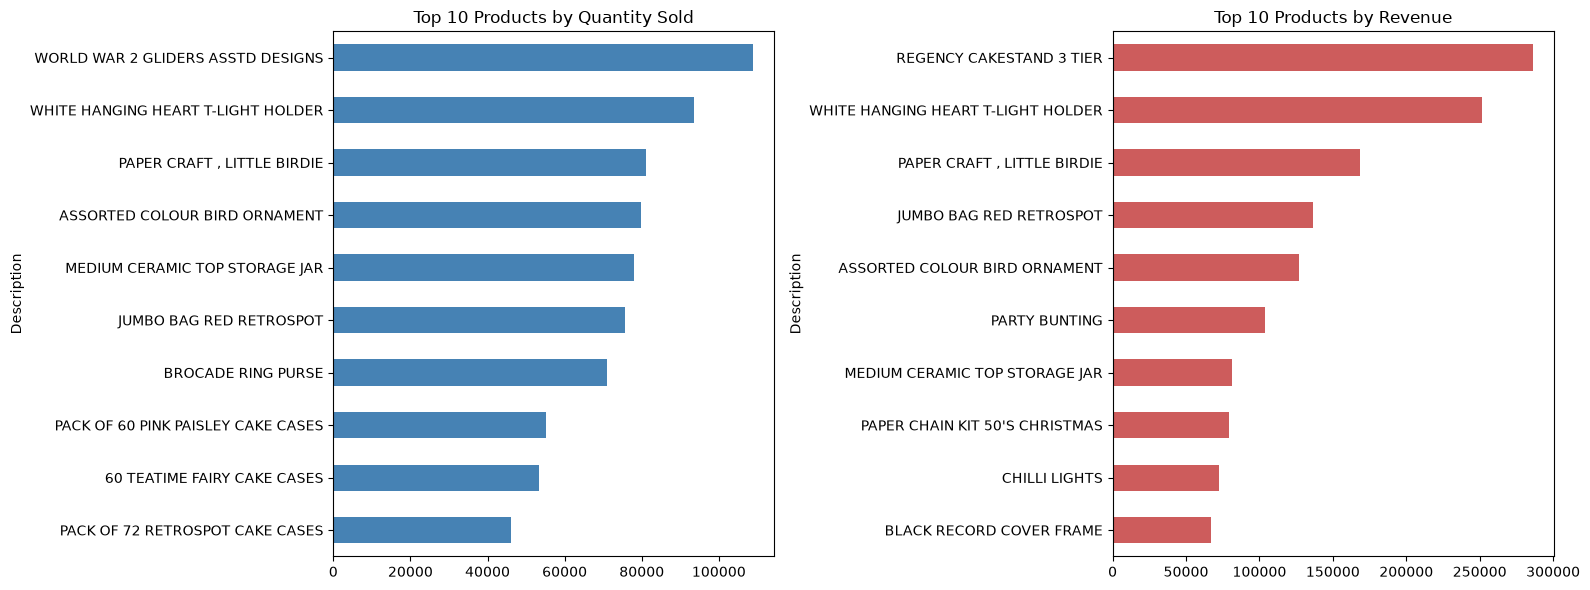

In [28]:
# -----------------------------------------------------------------------
# 4. Top products
# -----------------------------------------------------------------------
print("\n=== 4. TOP PRODUCTS ===")
top_products_qty = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 by quantity sold:\n", top_products_qty)
 
top_products_rev = df_clean.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 by revenue:\n", top_products_rev)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_products_qty.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Products by Quantity Sold')
 
top_products_rev.sort_values().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Top 10 Products by Revenue')
plt.tight_layout()
plt.show()


### 5. Sales by country


=========================== 5. SALES BY COUNTRY ==============================
Top 10 countries by revenue:
 Country
United Kingdom    1.456597e+07
EIRE              5.912099e+05
Netherlands       5.499510e+05
Germany           3.882711e+05
France            3.150636e+05
Australia         1.684172e+05
Spain             9.856147e+04
Switzerland       9.362434e+04
Sweden            8.604514e+04
Denmark           6.856019e+04
Name: Revenue, dtype: float64


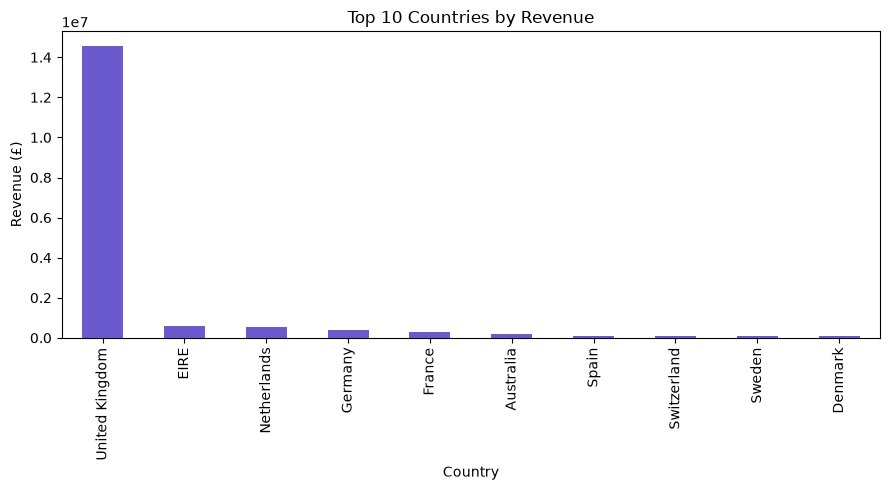

In [29]:
print("\n=========================== 5. SALES BY COUNTRY ==============================")
revenue_by_country = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print("Top 10 countries by revenue:\n", revenue_by_country.head(10))
plt.figure(figsize=(9, 5))
revenue_by_country.head(10).plot(kind='bar', color='slateblue')
plt.title('Top 10 Countries by Revenue')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()


Top 10 countries by order count:
 Country
United Kingdom    33361
Germany             753
France              590
EIRE                528
Netherlands         216
Spain               144
Belgium             143
Sweden               98
Australia            89
Portugal             83
Name: Invoice, dtype: int64

UK share of total revenue: 83.8%


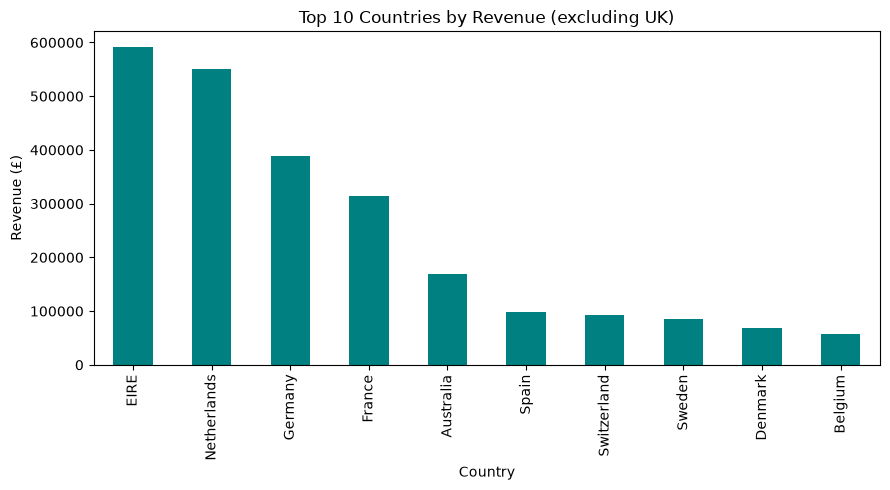

In [30]:
orders_by_country = df_clean.groupby('Country')['Invoice'].nunique().sort_values(ascending=False)
print("\nTop 10 countries by order count:\n", orders_by_country.head(10))

# UK dominates volume — show UK vs rest of world, and non-UK detail separately
uk_share = revenue_by_country.get('United Kingdom', 0) / revenue_by_country.sum() * 100
print(f"\nUK share of total revenue: {uk_share:.1f}%")
 

plt.figure(figsize=(9, 5))
revenue_by_country.drop('United Kingdom').head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Countries by Revenue (excluding UK)')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

### 6. Customer-level analysis


======================= 6. CUSTOMER-LEVEL ANALYSIS ================================
Orders per customer:
 count    5852.000000
mean        6.253247
std        12.749286
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       373.000000
Name: Invoice, dtype: float64

Top 10 customers by revenue:
 Customer ID
18102    608821.65
14646    526751.52
14156    303392.08
14911    276514.37
17450    246813.09
13694    196482.81
17511    175603.55
16446    168472.50
16684    147142.77
12415    144033.37
Name: Revenue, dtype: float64


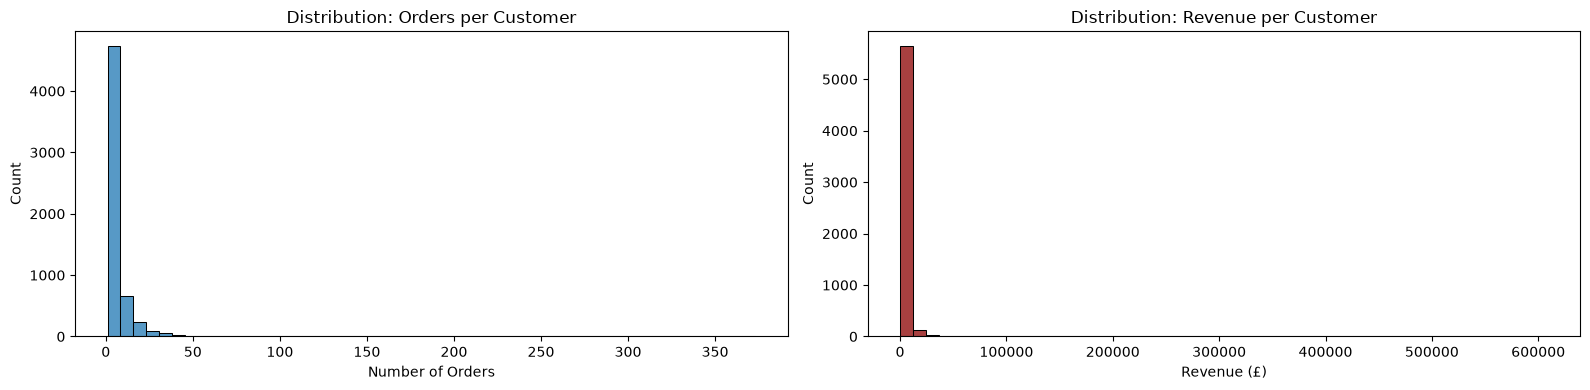


23.0% of customers generate 80% of revenue (1,348 of 5,852 customers)


In [31]:
print("\n======================= 6. CUSTOMER-LEVEL ANALYSIS ================================")
customer_orders = df_clean.groupby('Customer ID')['Invoice'].nunique().sort_values(ascending=False)
print("Orders per customer:\n", customer_orders.describe())
 
customer_revenue = df_clean.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
print("\nTop 10 customers by revenue:\n", customer_revenue.head(10))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(customer_orders, bins=50, ax=axes[0])
axes[0].set_title('Distribution: Orders per Customer')
axes[0].set_xlabel('Number of Orders')
 
sns.histplot(customer_revenue, bins=50, ax=axes[1], color='darkred')
axes[1].set_title('Distribution: Revenue per Customer')
axes[1].set_xlabel('Revenue (£)')
plt.tight_layout()
plt.show()
 
# Pareto check: what % of customers drive 80% of revenue?
cum_rev_share = (customer_revenue.sort_values(ascending=False).cumsum() / customer_revenue.sum())
n_customers_for_80pct = (cum_rev_share <= 0.80).sum() + 1
pct_customers_for_80pct = n_customers_for_80pct / len(customer_revenue) * 100
print(f"\n{pct_customers_for_80pct:.1f}% of customers generate 80% of revenue "
      f"({n_customers_for_80pct:,} of {len(customer_revenue):,} customers)")


### 7. Basket size


============================== 7. BASKET SIZE (items and value per order) ========================
       ItemsPerBasket  LineItemsPerBasket    BasketValue
count    36594.000000        36594.000000   36594.000000
mean       291.199732           20.935071     474.856120
std       1241.450207           22.404017    1374.086594
min          1.000000            1.000000       0.380000
25%         75.000000            7.000000     160.392500
50%        156.000000           15.000000     304.135000
75%        292.000000           27.000000     483.095000
max      87167.000000          540.000000  168469.600000


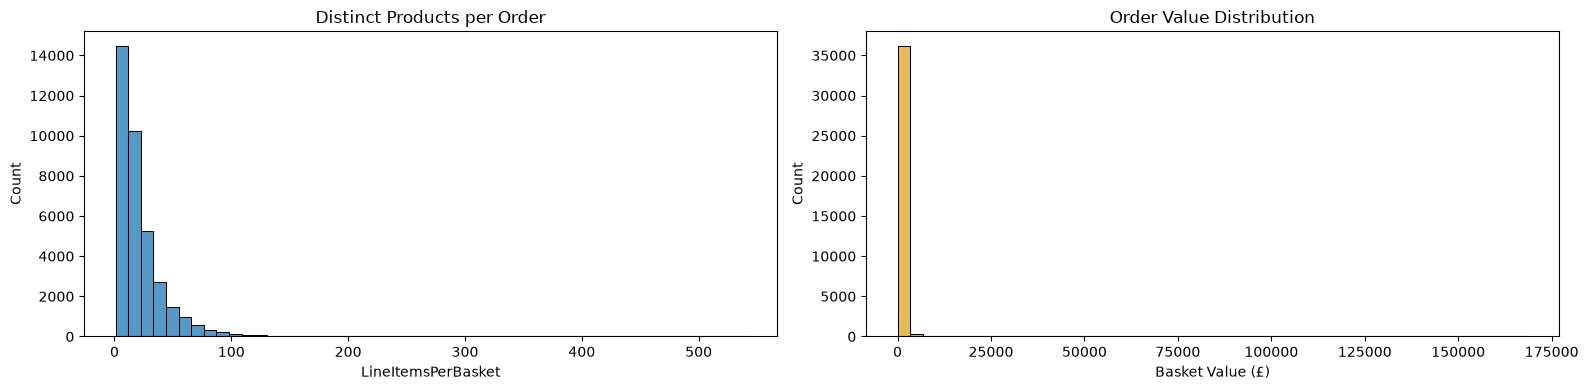

In [32]:
print("\n============================== 7. BASKET SIZE (items and value per order) ========================")
basket = df_clean.groupby('Invoice').agg(
    ItemsPerBasket=('Quantity', 'sum'),
    LineItemsPerBasket=('StockCode', 'nunique'),
    BasketValue=('Revenue', 'sum')
)
print(basket.describe())
 
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.histplot(basket['LineItemsPerBasket'], bins=50, ax=axes[0])
axes[0].set_title('Distinct Products per Order')
 
sns.histplot(basket['BasketValue'], bins=50, ax=axes[1], color='goldenrod')
axes[1].set_title('Order Value Distribution')
axes[1].set_xlabel('Basket Value (£)')
plt.tight_layout()
plt.show()

### 8. Returns exploration (df_returns, set aside during cleaning)

In [33]:
print("\n========================== 8. RETURNS / CANCELLATIONS ==============================")
print(f"Cancelled-order lines: {len(df_returns):,}")
print(f"Cancelled invoices: {df_returns['Invoice'].nunique():,} "
      f"({df_returns['Invoice'].nunique() / df_clean['Invoice'].nunique() * 100:.1f}% of sales invoice count)")
 
returns_by_country = df_returns.groupby('Country')['Invoice'].nunique().sort_values(ascending=False)
print("\nTop 5 countries by number of cancelled invoices:\n", returns_by_country.head(5))



========================== 8. RETURNS / CANCELLATIONS ==============================
Cancelled-order lines: 17,879
Cancelled invoices: 7,283 (19.9% of sales invoice count)

Top 5 countries by number of cancelled invoices:
 Country
United Kingdom    6492
Germany            282
EIRE               133
France             111
Belgium             29
Name: Invoice, dtype: int64


### 9. Correlation check


========================== 9. CORRELATIONS ===============================
          Quantity     Price   Revenue
Quantity  1.000000 -0.028258  0.833783
Price    -0.028258  1.000000  0.061013
Revenue   0.833783  0.061013  1.000000


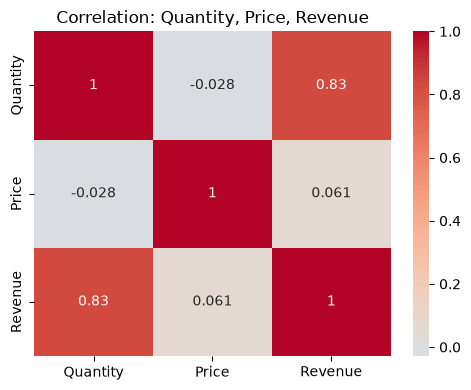

In [34]:
print("\n========================== 9. CORRELATIONS ===============================")
corr = df_clean[['Quantity', 'Price', 'Revenue']].corr()
print(corr)
 
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Quantity, Price, Revenue')
plt.tight_layout()
plt.show()


## Supervised Learning

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, accuracy_score, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
sns.set_style('whitegrid')

In [36]:
# 1. Time-based split
HOLDOUT_DAYS = 180  # "will they buy again in the next 6 months?"
cutoff = df_clean['InvoiceDate'].max() - pd.Timedelta(days=HOLDOUT_DAYS)
print(f"Feature window: up to {cutoff.date()}")
print(f"Outcome window: {cutoff.date()} to {df_clean['InvoiceDate'].max().date()}")

train_window = df_clean[df_clean['InvoiceDate'] < cutoff]
outcome_window = df_clean[df_clean['InvoiceDate'] >= cutoff]

active_before_cutoff = set(train_window['Customer ID'].unique())
active_after_cutoff = set(outcome_window['Customer ID'].unique())
print(f"Customers active before cutoff: {len(active_before_cutoff):,}")
print(f"Customers active after cutoff: {len(active_after_cutoff):,}")


Feature window: up to 2011-06-12
Outcome window: 2011-06-12 to 2011-12-09
Customers active before cutoff: 4,952
Customers active after cutoff: 3,472


In [37]:
# 2. Build features from PRE-CUTOFF data only
snapshot_date = cutoff

features = train_window.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum'),
    FirstPurchase=('InvoiceDate', 'min'),
    UniqueProducts=('StockCode', 'nunique'),
    TotalItems=('Quantity', 'sum'),
).reset_index()

features['Tenure'] = (snapshot_date - features['FirstPurchase']).dt.days
features['AvgOrderValue'] = features['Monetary'] / features['Frequency']
features['AvgItemsPerOrder'] = features['TotalItems'] / features['Frequency']
features['PurchaseRate'] = features['Frequency'] / features['Tenure'].replace(0, 1)
features = features.drop(columns=['FirstPurchase'])
features.head(5)

,Customer ID,Recency,Frequency,Monetary,UniqueProducts,TotalItems,Tenure,AvgOrderValue,AvgItemsPerOrder,PurchaseRate
0,12346,145,3,77352.96,25,74239,466,25784.320,24746.333333,0.006438
1,12347,2,5,3529.27,101,2141,223,705.854,428.200000,0.022422
2,12348,68,4,1388.40,24,2488,257,347.100,622.000000,0.015564
3,12349,227,2,2221.14,89,991,408,1110.570,495.500000,0.004902
4,12350,129,1,294.40,16,196,129,294.400,196.000000,0.007752



Churn rate in labeled set: 48.1%
Churned
0    2572
1    2380
Name: count, dtype: int64


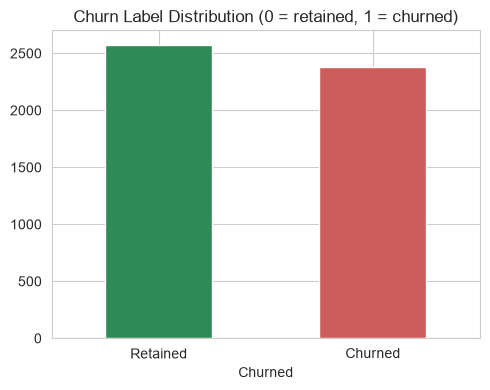

In [38]:
# 3. Label: churned = 1 if no purchase in the outcome window

features['Churned'] = (~features['Customer ID'].isin(active_after_cutoff)).astype(int)

print(f"\nChurn rate in labeled set: {features['Churned'].mean():.1%}")
print(features['Churned'].value_counts())

plt.figure(figsize=(5, 4))
features['Churned'].value_counts().plot(kind='bar', color=['seagreen', 'indianred'])
plt.title('Churn Label Distribution (0 = retained, 1 = churned)')
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.tight_layout()
plt.show()

In [39]:
# 4. Train / test split
feature_cols = ['Recency', 'Frequency', 'Monetary', 'Tenure',
                 'UniqueProducts', 'TotalItems', 'AvgOrderValue',
                 'AvgItemsPerOrder', 'PurchaseRate']

X = features[feature_cols]
y = features['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train):,} | Test size: {len(X_test):,}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train size: 3,714 | Test size: 1,238


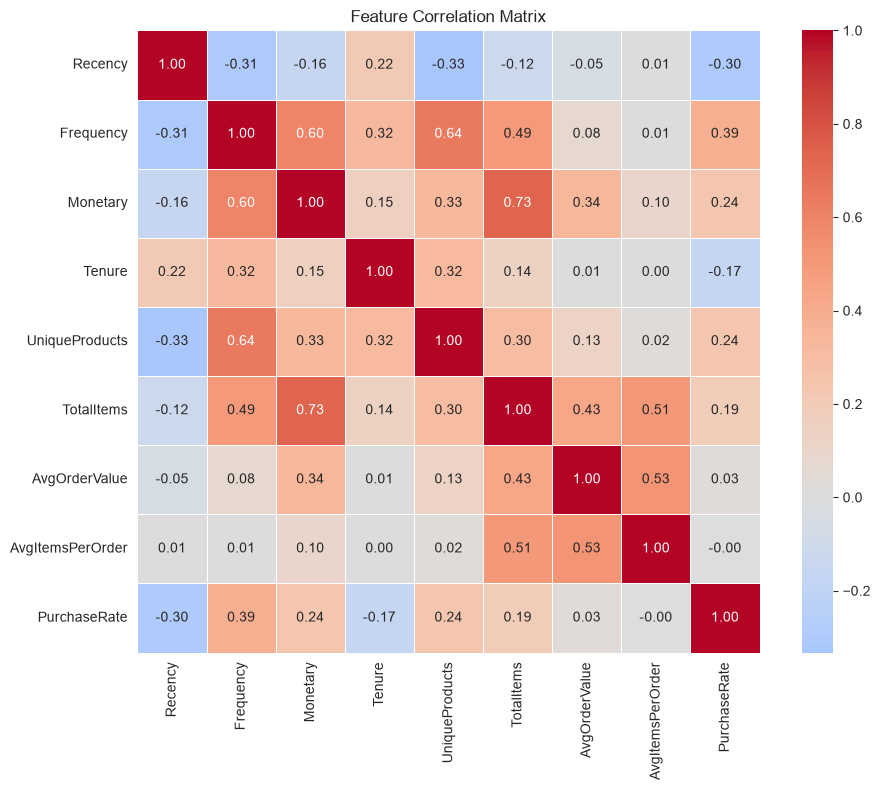

Highly correlated pairs (|r| > 0.8):


In [40]:
# 5. Correlation matrix
corr_matrix = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Flag pairs with high correlation (e.g. |r| > 0.8)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

print("Highly correlated pairs (|r| > 0.8):")
for pair in high_corr:
    print(pair)

In [41]:
# ==================== 6. Train models ====================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        # reg_alpha=0.1,        # L1 regularization
        reg_lambda=1.5,       # L2 regularization
        gamma=0.1,            # min loss reduction to split
        min_child_weight=3,   # min sum of instance weight in a child
        eval_metric='logloss',
        random_state=42
    )
}

results = {}
train_test_gap = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        y_pred_train = model.predict(X_train_scaled)
        y_proba_train = model.predict_proba(X_train_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred_train = model.predict(X_train)
        y_proba_train = model.predict_proba(X_train)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

    # Track train vs test AUC to check for overfitting
    train_test_gap[name] = {
        'train_auc': roc_auc_score(y_train, y_proba_train),
        'test_auc': roc_auc_score(y_test, y_proba),
    }
    train_test_gap[name]['gap'] = (
        train_test_gap[name]['train_auc'] - train_test_gap[name]['test_auc']
    )

In [42]:
# 7. Comparison of each regressor variable
# ---------- . Logistic Regression: standardized coefficients ----------
lr_model = results['Logistic Regression']['model']
lr_contributions = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0]),
    'Odds_Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print("=== Logistic Regression: Coefficients ===")
print(lr_contributions)

# ---------- Random Forest: Gini importance ----------
rf_model = results['Random Forest']['model']
rf_contributions = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n=== Random Forest: Feature Importance (Gini) ===")
print(rf_contributions)

# ---------- XGBoost: gain-based importance ----------
xgb_model = results['XGBoost']['model']
xgb_contributions = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Weight': xgb_model.feature_importances_  # default = 'gain' in sklearn API
}).sort_values('Importance_Weight', ascending=False).reset_index(drop=True)

print("\n=== XGBoost: Feature Importance (Gain) ===")
print(xgb_contributions)


=== Logistic Regression: Coefficients ===
            Feature  Coefficient  Abs_Coefficient  Odds_Ratio
0           Recency     0.877686         0.877686    2.405326
1         Frequency    -0.588344         0.588344    0.555246
2    UniqueProducts    -0.537243         0.537243    0.584357
3            Tenure    -0.164000         0.164000    0.848742
4      PurchaseRate    -0.111116         0.111116    0.894835
5          Monetary    -0.076037         0.076037    0.926782
6     AvgOrderValue    -0.055237         0.055237    0.946261
7  AvgItemsPerOrder     0.044761         0.044761    1.045778
8        TotalItems     0.016266         0.016266    1.016399

=== Random Forest: Feature Importance (Gini) ===
            Feature  Importance
0           Recency    0.231593
1      PurchaseRate    0.181420
2          Monetary    0.143649
3        TotalItems    0.128631
4         Frequency    0.092359
5    UniqueProducts    0.061327
6     AvgOrderValue    0.057705
7            Tenure    0.052414


In [43]:
# ==================== 8. Compare models ====================
print("\n==================== MODEL COMPARISON =============================")
comparison = pd.DataFrame({
    name: {k: v for k, v in res.items() if k not in ('model', 'y_pred', 'y_proba')}
    for name, res in results.items()
}).T
print(comparison)

print("\n==================== OVERFITTING CHECK (Train vs Test AUC) ========")
gap_df = pd.DataFrame(train_test_gap).T
print(gap_df)
print("\nNote: a large 'gap' (train_auc >> test_auc) suggests overfitting;")
print("a small gap with low scores overall may suggest underfitting.\n")


==================== MODEL COMPARISON =============================
                     accuracy  precision    recall        f1   roc_auc
Logistic Regression  0.726171   0.722222  0.699160  0.710504  0.796947
Random Forest        0.724556   0.705502  0.732773  0.718879  0.807060
XGBoost              0.726171   0.708469  0.731092  0.719603  0.801019

==================== OVERFITTING CHECK (Train vs Test AUC) ========
                     train_auc  test_auc       gap
Logistic Regression   0.801700  0.796947  0.004753
Random Forest         0.923530  0.807060  0.116471
XGBoost               0.911367  0.801019  0.110348

Note: a large 'gap' (train_auc >> test_auc) suggests overfitting;
a small gap with low scores overall may suggest underfitting.



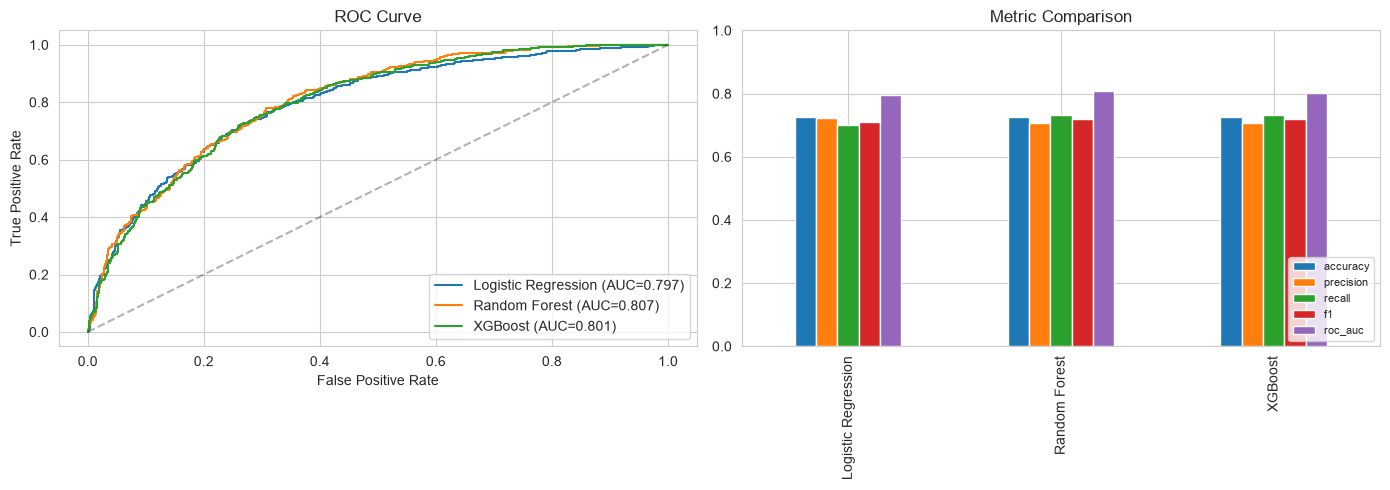

In [44]:

# ==================== 9. ROC curves + metric comparison ====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

comparison[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Metric Comparison')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

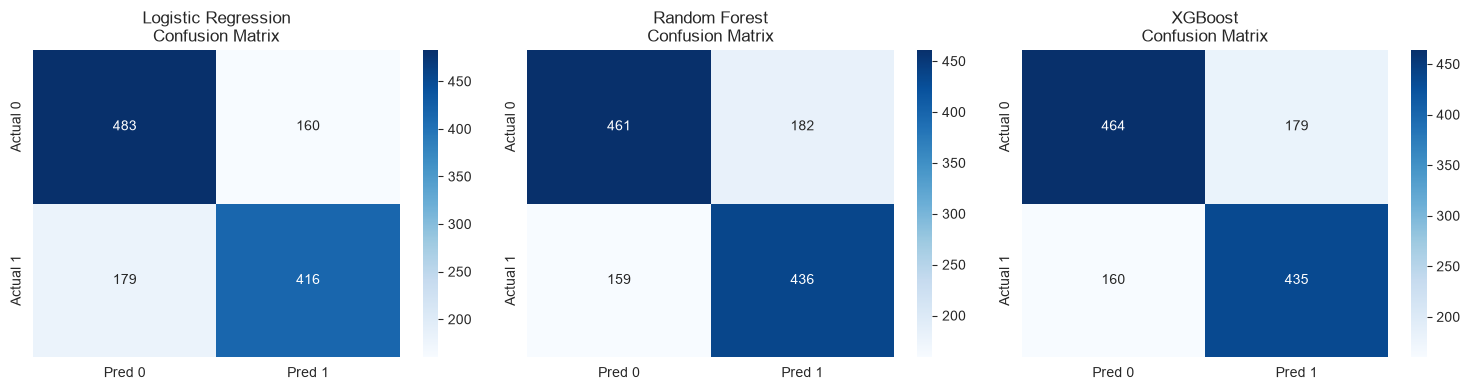

In [45]:
# ==================== 10. Confusion matrices ====================
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
if len(models) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    ax.set_title(f'{name}\nConfusion Matrix')

plt.tight_layout()
plt.show()

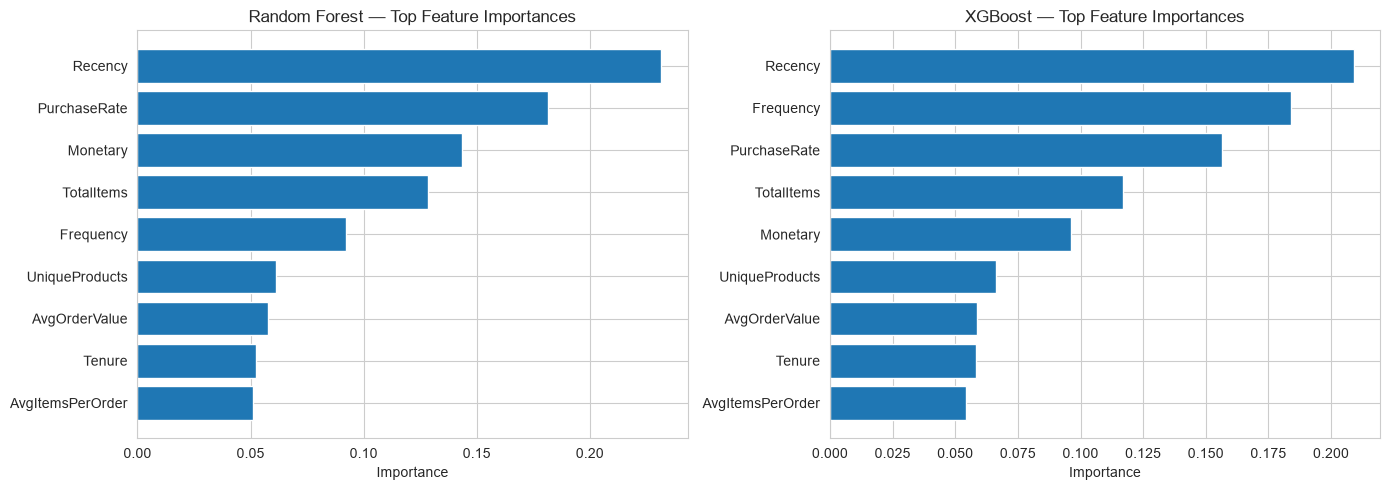

In [46]:

# ==================== 11. Feature importance (tree models) ====================
tree_models = {name: res['model'] for name, res in results.items()
               if name in ('Random Forest', 'XGBoost')}

fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 5))
if len(tree_models) == 1:
    axes = [axes]

feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'f{i}' for i in range(X_train.shape[1])]

for ax, (name, model) in zip(axes, tree_models.items()):
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:15]  # top 15 features
    ax.barh(range(len(idx)), importances[idx][::-1])
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels(np.array(feature_names)[idx][::-1])
    ax.set_title(f'{name} — Top Feature Importances')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [47]:
# 12. Pick best model (by ROC-AUC) and show detail
best_name = comparison['roc_auc'].idxmax()
best_result = results[best_name]
print(f"\n==================== BEST MODEL: {best_name} ===========================")
print(classification_report(y_test, best_result['y_pred'], target_names=['Retained', 'Churned']))


==================== BEST MODEL: Random Forest ===========================
              precision    recall  f1-score   support

    Retained       0.74      0.72      0.73       643
     Churned       0.71      0.73      0.72       595

    accuracy                           0.72      1238
   macro avg       0.72      0.72      0.72      1238
weighted avg       0.73      0.72      0.72      1238




=== FEATURE IMPORTANCE (Random Forest) ===
Recency             0.231593
PurchaseRate        0.181420
Monetary            0.143649
TotalItems          0.128631
Frequency           0.092359
UniqueProducts      0.061327
AvgOrderValue       0.057705
Tenure              0.052414
AvgItemsPerOrder    0.050901
dtype: float64


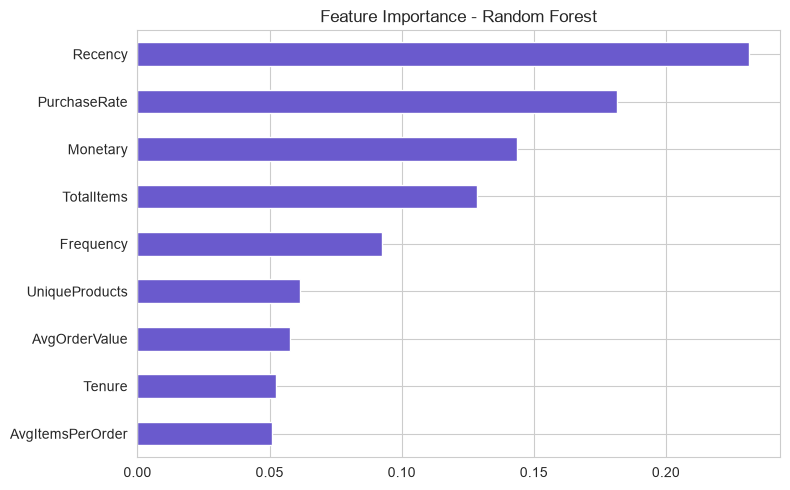

In [48]:
# 13. Feature importance (for the Model Interpretation step)
if best_name == 'Random Forest':
    importance = pd.Series(
        best_result['model'].feature_importances_, index=feature_cols
    ).sort_values(ascending=False)
else:
    importance = pd.Series(
        best_result['model'].coef_[0], index=feature_cols
    ).sort_values(key=abs, ascending=False)

print(f"\n=== FEATURE IMPORTANCE ({best_name}) ===")
print(importance)

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh', color='slateblue')
plt.title(f'Feature Importance - {best_name}')
plt.tight_layout()
plt.show()

# best_result['model'], X_test, y_test, feature_cols now ready for a
# deeper Model Interpretation step (e.g. SHAP values).